In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

import seaborn as sns


In [2]:
df_fact = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/steamUserFact.csv")
df_user = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/userDim.csv")
df_game = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/gameDim.csv", encoding="latin-1")

In [3]:
df_game['price_clean'] = pd.to_numeric(df_game['price']).fillna(0)

In [4]:
df_merged = df_fact.merge(df_game, on = 'game_id', how = 'inner')

In [5]:
user_stats = df_merged.groupby('steam_id').agg(
  total_games = ('game_id', 'count'),
  total_playtime = ('playtime_hours', 'sum'),
  avg_price = ('price_clean', 'mean')
).reset_index()

In [6]:
df_genres = df_merged[['steam_id', 'genres']].copy()
df_genres['genres'] = df_genres['genres'].fillna('Unknown').astype(str).str.split(',')
df_exploded = df_genres.explode('genres')

In [7]:
genre_counts = df_exploded.groupby(['steam_id', 'genres']).size().unstack(fill_value = 0)
top_genres = df_exploded['genres'].value_counts().head(8).index.tolist()
df_exploded = genre_counts[top_genres]

In [8]:
genre_pct = genre_counts.div(user_stats.set_index('steam_id')['total_games'], axis=0).fillna(0)
genre_pct.columns = [f"pct_{g.lower()}" for g in genre_pct.columns]

In [9]:
user_features = user_stats.merge(genre_pct, on = 'steam_id')
X = user_features.drop('steam_id', axis = 1).fillna(0)

In [10]:
scaler = StandardScaler()
user_feat_x = scaler.fit_transform(X)

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_features['cluster'] = kmeans.fit_predict(user_feat_x)

In [12]:
cluster_summary = user_features.groupby('cluster').mean()
print(cluster_summary)

             steam_id  total_games  total_playtime  avg_price  pct_action  \
cluster                                                                     
0        7.656120e+16    17.846703    52546.756458  17.221268    0.739544   
1        7.656120e+16    12.299962    17700.918714   6.355559    0.818254   
2        7.656120e+16    19.328125    43653.359375  18.085466    0.685395   
3        7.656120e+16    18.834356    39685.613497  13.207631    0.681823   

         pct_adventure  pct_animation &amp; modeling  pct_audio production  \
cluster                                                                      
0             0.279671                      0.000023              0.000016   
1             0.335465                      0.000006              0.000000   
2             0.326718                      0.043730              0.006766   
3             0.352571                      0.059282              0.000000   

         pct_casual  pct_design &amp; illustration  ...  pct_photo e

In [13]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)

    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])

    inertias.append(kmeanModel.inertia_)

    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

Distortion values:
1 : 3025374924.869688
2 : 1309310694.0052907
3 : 764345317.063728
4 : 505331337.50377834
5 : 348860041.0498721
6 : 259457721.26441726
7 : 207015811.0476801
8 : 150855819.10384133
9 : 119206950.28000982


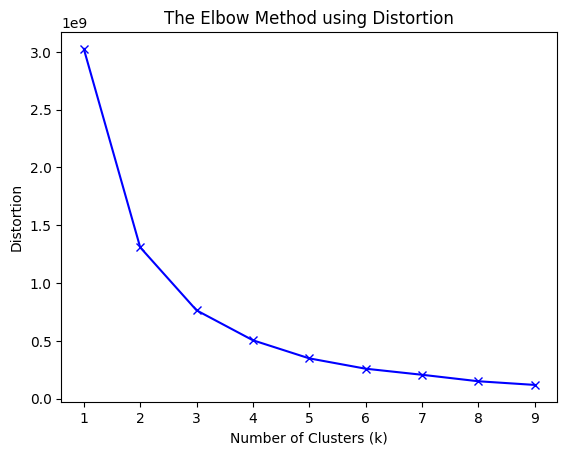

In [14]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

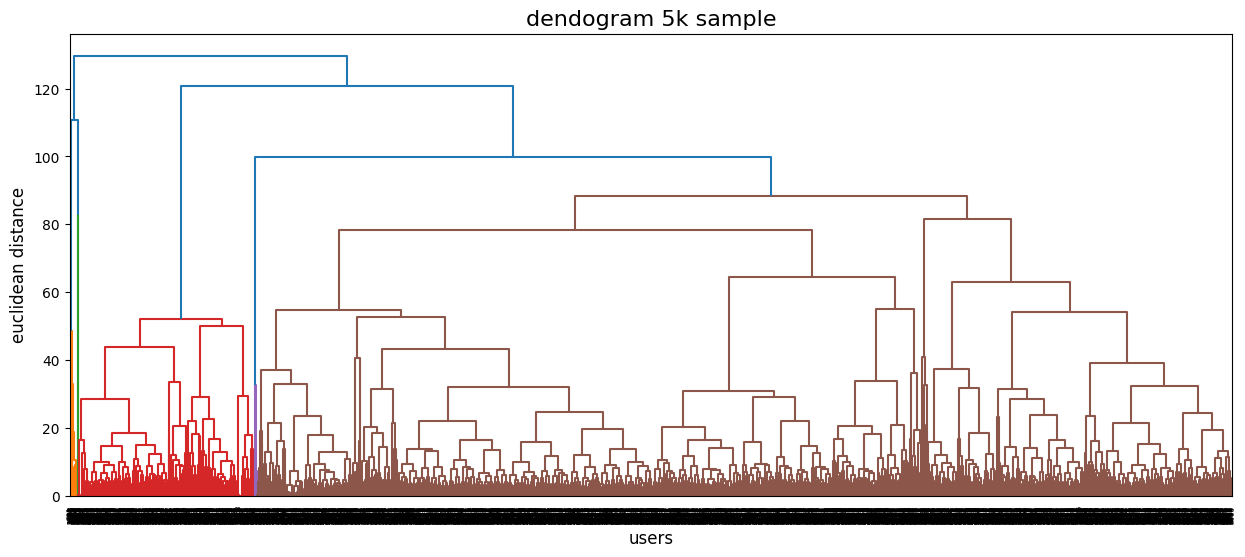

In [15]:
np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(user_feat_x.shape[0], size=sample_size, replace=False)

X_scaled_sample = user_feat_x[sample_indices]

plt.figure(figsize=(15, 6))
plt.title('dendogram 5k sample', fontsize=16)
plt.xlabel('users', fontsize=12)
plt.ylabel('euclidean distance', fontsize=12)

dendrogram = sch.dendrogram(sch.linkage(X_scaled_sample, method='ward'))
plt.show()


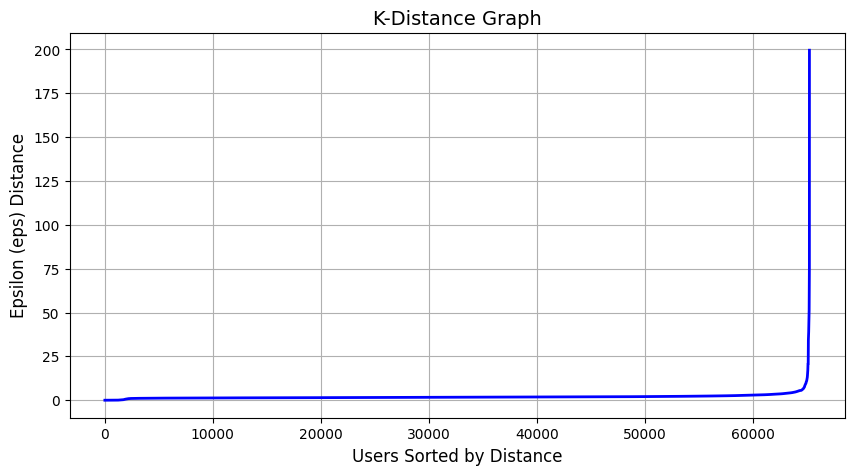

In [16]:
neighbors = NearestNeighbors(n_neighbors=50)
neighbors_fit = neighbors.fit(user_feat_x)
distances, indices = neighbors_fit.kneighbors(user_feat_x)

distances = np.sort(distances[:, 49], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='blue', linewidth=2)
plt.title('K-Distance Graph', fontsize=14)
plt.xlabel('Users Sorted by Distance', fontsize=12)
plt.ylabel('Epsilon (eps) Distance', fontsize=12)
plt.grid(True)
plt.show()

In [17]:
OPTIMAL_EPS = 3

dbscan = DBSCAN(eps=OPTIMAL_EPS, min_samples=50)
user_features['dbscan_cluster'] = dbscan.fit_predict(user_feat_x)

dbscan_summary = user_features.groupby('dbscan_cluster').mean().round(2)
dbscan_counts = user_features['dbscan_cluster'].value_counts().rename("user_count")

final_dbscan = pd.concat([dbscan_counts, dbscan_summary], axis=1)
print("DB_Scan:", final_dbscan.T)

DB_Scan: dbscan_cluster                            0            -1             1  \
user_count                     6.240700e+04  1.942000e+03  2.790000e+02   
steam_id                       7.656120e+16  7.656120e+16  7.656120e+16   
total_games                    1.635000e+01  8.380000e+00  1.889000e+01   
total_playtime                 4.141764e+04  4.266779e+04  4.321939e+04   
avg_price                      1.369000e+01  1.664000e+01  1.336000e+01   
pct_action                     7.700000e-01  5.900000e-01  7.600000e-01   
pct_adventure                  2.900000e-01  3.000000e-01  2.900000e-01   
pct_animation &amp; modeling   0.000000e+00  1.000000e-02  0.000000e+00   
pct_audio production           0.000000e+00  0.000000e+00  0.000000e+00   
pct_casual                     1.100000e-01  2.300000e-01  1.200000e-01   
pct_design &amp; illustration  0.000000e+00  1.000000e-02  0.000000e+00   
pct_early access               4.000000e-02  9.000000e-02  5.000000e-02   
pct_education   

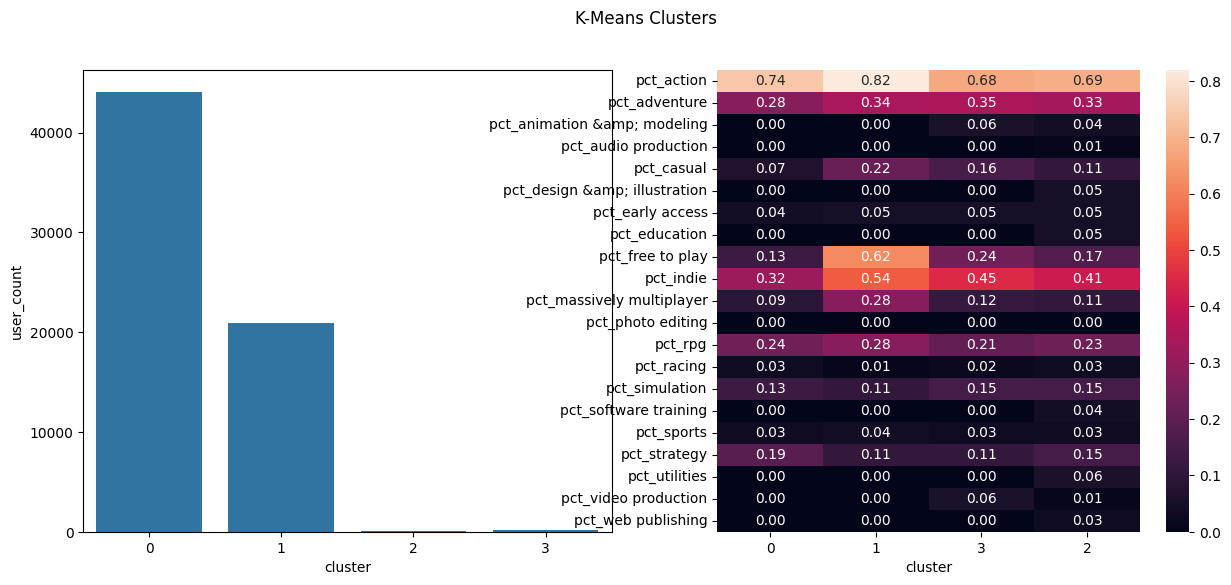

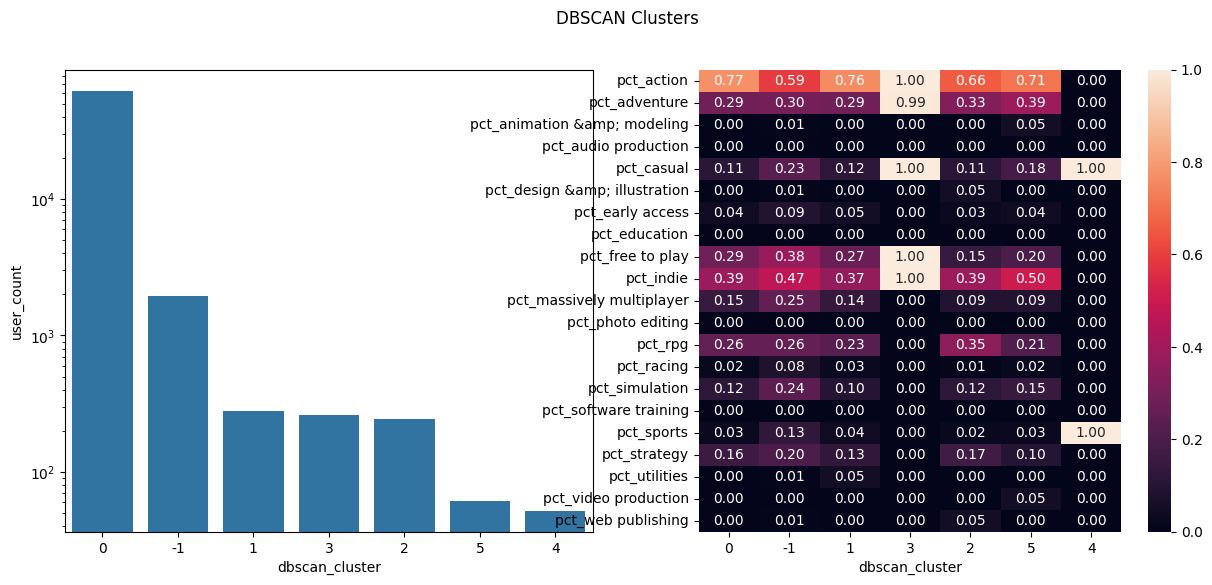

In [18]:
cluster_summary = user_features.groupby('cluster').mean().round(2)
cluster_counts = user_features['cluster'].value_counts().rename("user_count")
final_summary = pd.concat([cluster_counts, cluster_summary], axis=1)

genre_cols = [col for col in final_dbscan.columns if col.startswith('pct_')]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=final_summary.index, y=final_summary['user_count'], ax=axes[0])
sns.heatmap(final_summary[genre_cols].T, annot=True, fmt=".2f", ax=axes[1])
plt.suptitle('K-Means Clusters')
plt.show()

dbscan_sorted = final_dbscan.sort_values('user_count', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=dbscan_sorted.index, y=dbscan_sorted['user_count'], order=dbscan_sorted.index, ax=axes[0])
axes[0].set_yscale('log') 
sns.heatmap(dbscan_sorted[genre_cols].T, annot=True, fmt=".2f", ax=axes[1])
plt.suptitle('DBSCAN Clusters')
plt.show()

                           label                                                    marketing                                                                 recommendation                                                               retention
cluster                                                                                                                                                                                                                                             
0        Mainstream Action Gamer                 Promote AAA releases, DLC, franchise sequels             Top-rated action/adventure, upcoming releases in wishlisted genres                  Early access offers, loyalty discounts on new releases
1            Free-to-Play Casual        In-game cosmetics, battle passes, limited-time events                 Trending F2P titles, multiplayer games with active communities  Seasonal event reminders, social hooks (friend activity, leaderboards)
3               Indi

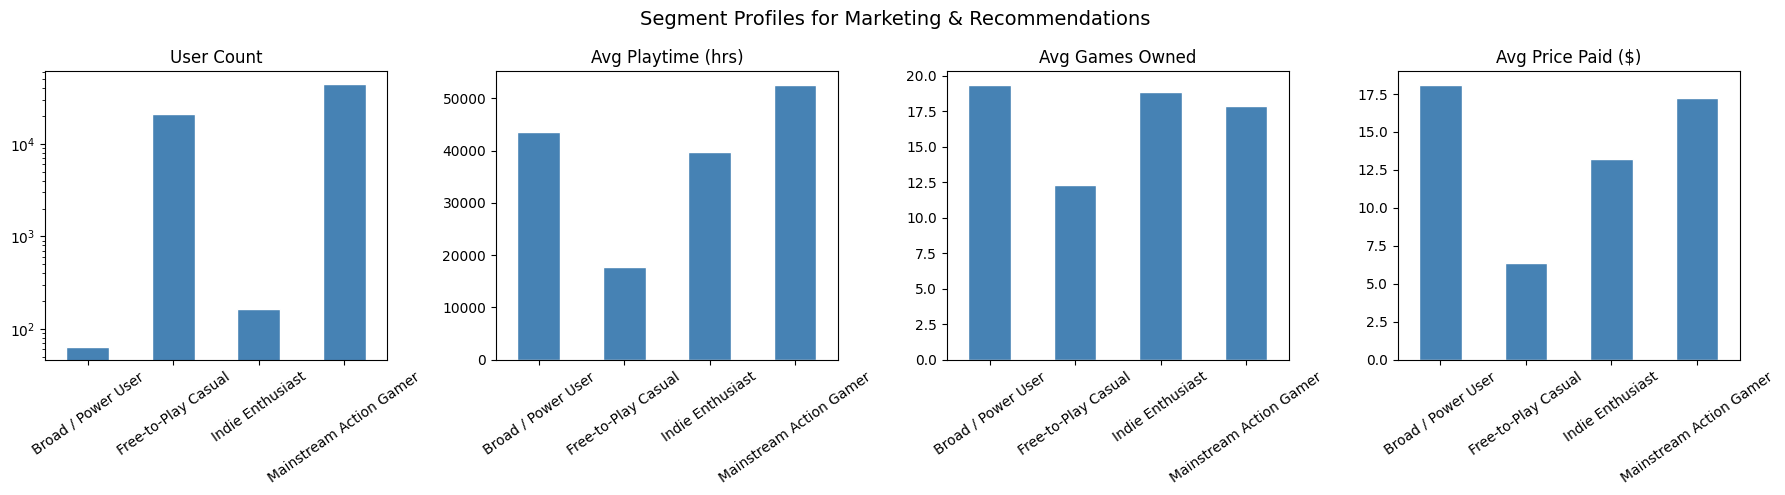

In [19]:
cluster_profiles = {
    0: {
        'label': 'Mainstream Action Gamer',
        'marketing': 'Promote AAA releases, DLC, franchise sequels',
        'recommendation': 'Top-rated action/adventure, upcoming releases in wishlisted genres',
        'retention': 'Early access offers, loyalty discounts on new releases'
    },
    1: {
        'label': 'Free-to-Play Casual',
        'marketing': 'In-game cosmetics, battle passes, limited-time events',
        'recommendation': 'Trending F2P titles, multiplayer games with active communities',
        'retention': 'Seasonal event reminders, social hooks (friend activity, leaderboards)'
    },
    3: {
        'label': 'Indie Enthusiast',
        'marketing': 'Indie bundles, developer spotlights, curated collections',
        'recommendation': 'Hidden gem indies, games by followed developers, festival picks',
        'retention': 'Wishlist sale alerts, early access invites, developer update emails'
    },
    2: {
        'label': 'Broad / Power User',
        'marketing': 'Cross-sell software, creative tools, Steam Labs experiments',
        'recommendation': 'Surface tools and non-gaming content alongside games based on recent activity',
        'retention': 'Personalised weekly digest, feature discovery nudges'
    }
}

strategy_df = pd.DataFrame(cluster_profiles).T
strategy_df.index.name = 'cluster'
print(strategy_df.to_string())

label_map = {k: v['label'] for k, v in cluster_profiles.items()}
user_features['segment_label'] = user_features['cluster'].map(label_map)

segment_summary = user_features.groupby('segment_label').agg(
    user_count=('steam_id', 'count'),
    avg_playtime=('total_playtime', 'mean'),
    avg_games=('total_games', 'mean'),
    avg_spend=('avg_price', 'mean')
).round(2)

print(segment_summary)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = {
    'user_count': 'User Count',
    'avg_playtime': 'Avg Playtime (hrs)',
    'avg_games': 'Avg Games Owned',
    'avg_spend': 'Avg Price Paid ($)'
}

for ax, (col, title) in zip(axes, metrics.items()):
    segment_summary[col].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    ax.set_xlabel('')
    if col == 'user_count':
        ax.set_yscale('log')

plt.suptitle('Segment Profiles for Marketing & Recommendations', fontsize=14)
plt.tight_layout()
plt.show()

# results
K-Means gives a clean 4-cluster solution that holds up well for practical segmentation , the dominant action/indie mainstream, a free-to-play casual group, and two smaller but distinct niches. DBSCAN broadly agrees on the main structure but surfaces some interesting micro-clusters (eg. pure sports or casual-only users) that K-Means does not show. The noise group (eg. 1,500 users) is worth noting too , because some users just don't fit into a clear pattern that the dbscan can pick up on.